# MS4 — Behavior-Signal Alignment for Generative Recommenders

**AC209B Final Project · Group 14 **

| Member | Email |
|---|---|
| Ji Zhang | jizhang@g.harvard.edu |
| Mengchu Yue | mengchuyue@fas.harvard.edu |
| Xiaoyu Yang | xiaoyu_yang1@g.harvard.edu |

This Notebook is created assited by Claude Code.

---

## §1 What this project is about

Modern recommender systems increasingly cast recommendation as a *next-item generation* problem. Rather than scoring every candidate item with a separate retrieval-and-ranking pipeline, a **generative recommender** takes a user's history as context and generates item identifiers for the next set of recommendations directly, the same way a language model generates the next sentence.

[**OneRec**](https://github.com/Kuaishou-OneRec/OpenOneRec) (Kuaishou, 2025) is one such generative recommender. It represents each video as a sequence of three "semantic ID" tokens drawn from a small codebook ($K \approx 8{,}192$ per position) and is trained autoregressively on logged user histories from the Kuaishou short-video platform.

Standard generative-recommender training treats the **logged future window** as the target: the model is rewarded for recovering items the historical recommender served to the user. But **exposure is not preference** — a video can appear in the logged future window because the old system served it, even if the user skipped it or marked it not-interested. Behavior signals such as longview, like, follow, and forward are stronger evidence of genuine user engagement.

OneRec's published pipeline handles this gap by training an **additional reward model** and running an iterative preference-alignment stage. We ask a simpler question:

> **In offline logs where behavior signals are already available per-item, can we construct preference supervision directly from behavior signals and skip the reward model entirely?**

The rest of this notebook walks through how we approached and answered this question. The headline answer (which we substantiate over the next 10 sections): **yes — plain supervised fine-tuning on behavior-positive items removes the baseline's strong anti-alignment without any reward model**, and a structural finding explains why more sophisticated contrastive objectives (ORPO, DPO with anchor) do not improve on plain SFT in this regime.

---

## §2 Setup

This notebook reads from three locations:

| Path | Purpose | Size |
|---|---|---|
| `data/OpenOneRec/onerec_bench_release.parquet` | main user-level dataset, 162k users (full) | 1.6 GB |
| `data/sample/onerec_master_sample_1k.parquet`  | 1k-user subsample shipped with this notebook | ≈ 3 MB |
| `evaluation_results/*.json`                    | cached evaluation summaries for our four 50k arms | < 1 MB |
| `runs/{sft_only_50k, orpo_50k, dpo_anchor_from_sft_50k}/checkpoint-6250/trainer_state.json` | training-time evaluation trajectories | < 1 MB each |

**Data resolution.** The submitted zip ships only the 1k-user sample. The notebook tries, in order: (1) local 1.6 GB parquet if present (developer machines), (2) Hugging Face Hub download of the full parquet from `SeeEne/onerec-209b-runs:data/onerec_bench_release.parquet`, (3) the bundled 1k-user sample. All three paths produce a valid `DataFrame` with identical schema; aggregate counts in §4 will differ proportionally to user count.

Most cells are **runnable** on a laptop (pandas + matplotlib only). Training and inference cells are commented out with hardware requirements clearly marked.

In [38]:
# Imports — pandas, numpy, matplotlib, no GPU dependencies.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
})

In [39]:
# Paths.  This notebook lives at the project root.
PROJECT_ROOT = Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"
EVAL_DIR     = PROJECT_ROOT / "evaluation_results"
RUNS_DIR     = PROJECT_ROOT / "runs"

for name, p in [("PROJECT_ROOT", PROJECT_ROOT), ("DATA_DIR", DATA_DIR),
                ("EVAL_DIR", EVAL_DIR), ("RUNS_DIR", RUNS_DIR)]:
    status = "OK" if p.exists() else "MISSING"
    print(f"{name:>14s}: {p}  [{status}]")

  PROJECT_ROOT: /Users/ender_yang/Desktop/HU/Spring26/209B/project  [OK]
      DATA_DIR: /Users/ender_yang/Desktop/HU/Spring26/209B/project/data  [OK]
      EVAL_DIR: /Users/ender_yang/Desktop/HU/Spring26/209B/project/evaluation_results  [OK]
      RUNS_DIR: /Users/ender_yang/Desktop/HU/Spring26/209B/project/runs  [OK]


In [40]:
# Data resolution: local full -> HF Hub -> bundled 1k sample.
FULL_LOCAL   = DATA_DIR / "OpenOneRec" / "onerec_bench_release.parquet"
SAMPLE_LOCAL = DATA_DIR / "sample" / "onerec_master_sample_1k.parquet"
HF_REPO      = "SeeEne/onerec-209b-runs"
HF_FILE      = "data/onerec_bench_release.parquet"

def resolve_data_path(allow_hf_download: bool = True) -> Path:
    if FULL_LOCAL.exists():
        print(f"[data] using local full parquet  "
              f"({FULL_LOCAL.stat().st_size / 1e9:.2f} GB)")
        return FULL_LOCAL

    if allow_hf_download:
        try:
            from huggingface_hub import hf_hub_download
            print(f"[data] local full parquet missing; pulling from HF Hub:")
            print(f"       {HF_REPO}:{HF_FILE}  (1.6 GB, will be cached)")
            cached = hf_hub_download(repo_id=HF_REPO, filename=HF_FILE, repo_type="model")
            print(f"[data] downloaded to {cached}")
            return Path(cached)
        except Exception as e:
            print(f"[data] HF download failed: {type(e).__name__}: {e}")

    if SAMPLE_LOCAL.exists():
        print(f"[data] falling back to bundled 1k-user sample  "
              f"({SAMPLE_LOCAL.stat().st_size / 1e6:.2f} MB)")
        print("[data] note: aggregate counts in §4 will scale with user count;")
        print("       full-dataset numbers reported in markdown are from the 162k run.")
        return SAMPLE_LOCAL

    raise FileNotFoundError("Neither local full nor bundled sample is available.")

# Set allow_hf_download=False to force the local-or-sample path (faster).
DATA_PATH = resolve_data_path(allow_hf_download=True)

[data] using local full parquet  (1.72 GB)


---

## §3 Dataset structure

OpenOneRec provides per-user records with separate **history** and **target** windows. Each window stores the video PID (item ID) plus five binary behavior signals per item: `longview`, `like`, `follow`, `forward`, `not_interested`. Arrays in each column are **zero-padded to a fixed length** (502 for history, 10 for target), so the *effective* length per user is found by counting non-zero entries.

Each PID maps to a 3-token semantic ID $\langle s_a^x, s_b^y, s_c^z \rangle$ via `data/OpenOneRec/video_ad_pid2sid.parquet` (15.9M videos, codebook size $K = 8{,}192$ per token position). The generative model produces those SID token sequences rather than raw PIDs — we do not load the mapping in this notebook since it is downstream of dataset analysis (see `train/dataset.py` for the runtime usage).

In [41]:
# Load the parquet resolved above.
df = pd.read_parquet(DATA_PATH)
print(f"Total rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
print("Split distribution (split=0 is the training table; the held-out OneRec")
print("benchmark lives in a separate parquet under data/OpenOneRec/benchmark_data/):")
print(df["split"].value_counts())

Total rows: 162,074
Columns: 25

Split distribution (split=0 is the training table; the held-out OneRec
benchmark lives in a separate parquet under data/OpenOneRec/benchmark_data/):
split
0    162074
Name: count, dtype: int64


In [42]:
# Column layout — grouped for readability.
hist_cols = [c for c in df.columns if c.startswith("hist_video_")]
tgt_cols  = [c for c in df.columns if c.startswith("target_video_")]
other     = [c for c in df.columns if c not in hist_cols + tgt_cols + ["uid", "split"]]

print("Identity:  uid, split\n")
print("History window (zero-padded to length 502):")
for c in hist_cols:
    print(f"  {c}")
print("\nTarget window (zero-padded to length 10) — this is where our chosen/rejected")
print("split is constructed:")
for c in tgt_cols:
    print(f"  {c}")
if other:
    print("\nOther columns (not used by this project; may be absent in the bundled sample):")
    for c in other:
        print(f"  {c}")

Identity:  uid, split

History window (zero-padded to length 502):
  hist_video_follow
  hist_video_forward
  hist_video_like
  hist_video_longview
  hist_video_not_interested
  hist_video_pid

Target window (zero-padded to length 10) — this is where our chosen/rejected
split is constructed:
  target_video_follow
  target_video_forward
  target_video_like
  target_video_longview
  target_video_not_interested
  target_video_pid

Other columns (not used by this project; may be absent in the bundled sample):
  hist_ad_pid
  target_ad_pid
  hist_goods_pid
  target_goods_pid
  inter_keyword_to_items
  inter_user_profile_with_pid
  inter_user_profile_with_sid
  reco_gsu_caption
  reco_target_caption
  reco_cot
  hist_longview_video_list


In [43]:
# Filter to training split. Compute effective lengths (count non-zero PIDs).
master = df[df["split"] == 0].reset_index(drop=True)

hist_len = master["hist_video_pid"].apply(lambda a: int((np.asarray(a) != 0).sum()))
tgt_len  = master["target_video_pid"].apply(lambda a: int((np.asarray(a) != 0).sum()))

n_eligible = int((tgt_len > 0).sum())

print(f"split=0 (training table): {len(master):,} users")
print(f"Users with non-empty target window: {n_eligible:,}")
print()
print(f"History length:   mean={hist_len.mean():.1f}, median={int(hist_len.median())}, "
      f"max={int(hist_len.max())}")
print(f"Target length:    mean={tgt_len.mean():.2f}, median={int(tgt_len.median())}, "
      f"max={int(tgt_len.max())}")
print()
print("Full-dataset reference (n=162,074 users from the 162k master parquet):")
print("  mean history length ≈ 380.5, mean target-window length ≈ 8.60")

split=0 (training table): 162,074 users
Users with non-empty target window: 162,074

History length:   mean=458.3, median=484, max=512
Target length:    mean=8.64, median=9, max=10

Full-dataset reference (n=162,074 users from the 162k master parquet):
  mean history length ≈ 380.5, mean target-window length ≈ 8.60


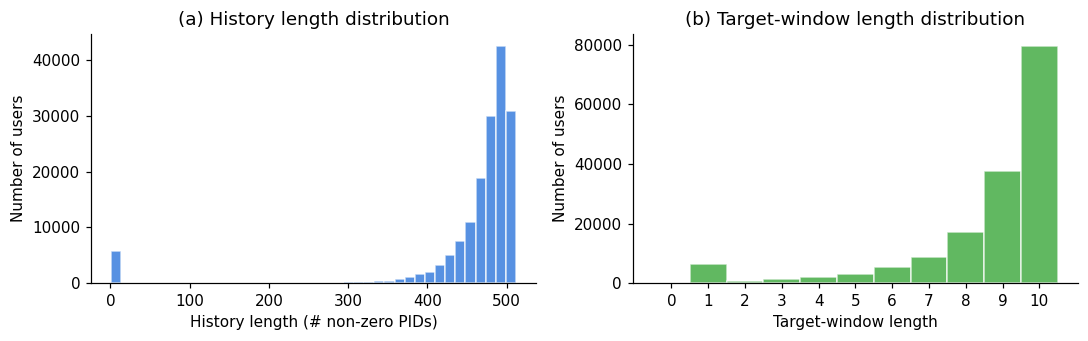

In [44]:
# Visualize length distributions.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))

ax1.hist(hist_len, bins=40, color="#1f6dd9", alpha=0.75, edgecolor="white")
ax1.set_xlabel("History length (# non-zero PIDs)")
ax1.set_ylabel("Number of users")
ax1.set_title("(a) History length distribution")
for sp in ("top", "right"):
    ax1.spines[sp].set_visible(False)

ax2.hist(tgt_len, bins=range(0, 12), color="#2ca02c", alpha=0.75,
         edgecolor="white", align="left")
ax2.set_xlabel("Target-window length")
ax2.set_ylabel("Number of users")
ax2.set_title("(b) Target-window length distribution")
ax2.set_xticks(range(11))
for sp in ("top", "right"):
    ax2.spines[sp].set_visible(False)

fig.tight_layout()
plt.show()

---

## §4 Behavior signals breakdown

Each target-window item carries five binary behavior flags. Following the paper's §3 definition:

- **Positive engagement**: $z^+_{u,j} = \mathbf{1}[\mathrm{longview} \lor \mathrm{like} \lor \mathrm{follow} \lor \mathrm{forward}]$
- **Explicit rejection**: $z^-_{u,j} = 1$ if `not_interested = 1`
- **Implicit rejection (exposed but not engaged)**: $z^-_{u,j} = 1$ if exposed and $z^+_{u,j} = 0$

The aggregate breakdown is *operationally critical*: explicit `not_interested` is extremely rare (about 0.1% of rejected items), so a hard-negative-only construction would yield almost no preference pairs. We treat exposed-but-non-engaged as weak rejects.

In [45]:
# Aggregate over all rows. Row-wise iteration is robust to variable-length
# arrays in the full master parquet (where a handful of rows may have arrays
# shorter than 10 due to upstream truncation).
POSITIVE_SIGNALS = ["longview", "like", "follow", "forward"]
NEGATIVE_SIGNAL  = "not_interested"

n_target_items   = 0
n_positive       = 0
n_neg_explicit   = 0
n_rej_no_signal  = 0
signal_counts    = {sig: 0 for sig in POSITIVE_SIGNALS}
n_multi          = 0

for _, row in master.iterrows():
    pids = np.asarray(row["target_video_pid"])
    valid = pids != 0
    if not valid.any():
        continue
    sig_arr = {sig: np.asarray(row[f"target_video_{sig}"]) for sig in POSITIVE_SIGNALS + [NEGATIVE_SIGNAL]}
    is_pos  = np.zeros_like(valid, dtype=bool)
    for sig in POSITIVE_SIGNALS:
        is_pos |= (sig_arr[sig] == 1)
    is_pos &= valid

    is_neg_exp = (sig_arr[NEGATIVE_SIGNAL] == 1) & valid
    n_target_items  += int(valid.sum())
    n_positive      += int(is_pos.sum())
    n_neg_explicit  += int(is_neg_exp.sum())
    n_rej_no_signal += int((valid & ~is_pos & ~is_neg_exp).sum())

    n_per_item = np.zeros_like(valid, dtype=int)
    for sig in POSITIVE_SIGNALS:
        sig_match = (sig_arr[sig] == 1) & valid
        signal_counts[sig] += int(sig_match.sum())
        n_per_item += sig_match.astype(int)
    n_multi += int(((n_per_item >= 2) & is_pos).sum())

n_rejected_total = n_neg_explicit + n_rej_no_signal

print(f"Total target items in this run: {n_target_items:>10,}")
print()
print("Aggregate split (this run / full 162k reference in parens):")
print(f"  positive (chosen):                  {n_positive:>10,}  "
      f"({100*n_positive/n_target_items:5.1f}%)   [full: ~437,288]")
print(f"  rejected, no positive signal:       {n_rej_no_signal:>10,}  "
      f"({100*n_rej_no_signal/n_target_items:5.1f}%)  [full: ~695,486]")
print(f"  rejected, explicit not-interested:  {n_neg_explicit:>10,}  "
      f"({100*n_neg_explicit/n_target_items:5.1f}%)  [full: ~687]")
print()
print(f"Among rejected items: explicit not-interested is only "
      f"{100*n_neg_explicit/max(1, n_rejected_total):.2f}% — confirming")
print("the sparsity argument for treating exposed-non-engaged items as weak rejects.")

Total target items in this run:  1,400,451

Aggregate split (this run / full 162k reference in parens):
  positive (chosen):                     497,504  ( 35.5%)   [full: ~437,288]
  rejected, no positive signal:          902,271  ( 64.4%)  [full: ~695,486]
  rejected, explicit not-interested:         853  (  0.1%)  [full: ~687]

Among rejected items: explicit not-interested is only 0.09% — confirming
the sparsity argument for treating exposed-non-engaged items as weak rejects.


In [46]:
# Per-positive-signal breakdown — what kind of engagement dominates?
print(f"Per-signal breakdown of {n_positive:,} positive items in this run:")
for sig, cnt in signal_counts.items():
    print(f"  {sig:<10s} {cnt:>10,}  ({100*cnt/max(1,n_positive):5.1f}% of positives)")
print(f"  multi-signal (>= 2): {n_multi:>5,}  "
      f"({100*n_multi/max(1,n_positive):.1f}% of positives)")
print()
print("Full 162k reference: longview ≈ 72%, like ≈ 25%, multi-signal ≈ 0.8%.")
print("Longview alone dominates — most 'engaged' items in this dataset are")
print("watched-to-completion rather than explicitly liked, followed, or shared.")

Per-signal breakdown of 497,504 positive items in this run:
  longview      404,598  ( 81.3% of positives)
  like          130,816  ( 26.3% of positives)
  follow          3,673  (  0.7% of positives)
  forward         9,604  (  1.9% of positives)
  multi-signal (>= 2): 48,838  (9.8% of positives)

Full 162k reference: longview ≈ 72%, like ≈ 25%, multi-signal ≈ 0.8%.
Longview alone dominates — most 'engaged' items in this dataset are
watched-to-completion rather than explicitly liked, followed, or shared.


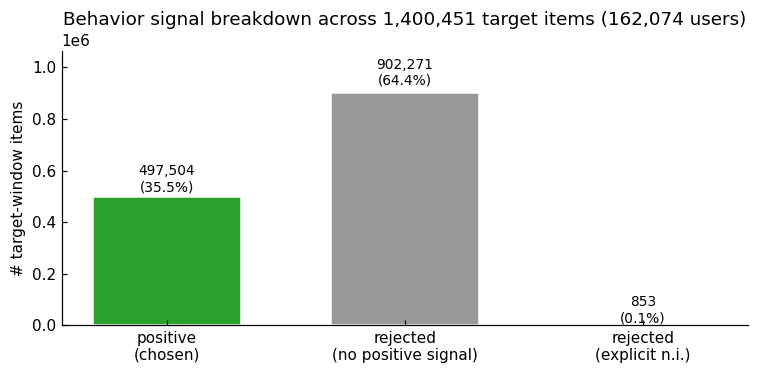

In [47]:
# Bar chart of the three-way split (this run's numbers).
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ["positive\n(chosen)", "rejected\n(no positive signal)", "rejected\n(explicit n.i.)"]
counts = [n_positive, n_rej_no_signal, n_neg_explicit]
colors = ["#2ca02c", "#999999", "#d62728"]

bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.62)
for bar, cnt in zip(bars, counts):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
            f"{cnt:,}\n({100*cnt/max(1,n_target_items):.1f}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("# target-window items")
ax.set_title(f"Behavior signal breakdown across {n_target_items:,} target items "
             f"({len(master):,} users)")
ax.set_ylim(0, max(counts) * 1.18)
ax.tick_params(direction="in")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

fig.tight_layout()
plt.show()

---

## §5 The engagement insight — same window, very different feedback

The numbers above are aggregate. To see why "next-shown $\neq$ engaged" is a *per-user* problem and not just an average artifact, let's pick a single user and look at what their logged future window actually contained.

We use a deterministic search (take the first eligible user with at least 3 chosen and 3 rejected items, so the same user supplies the pair construction in §6) for reproducibility.

In [48]:
# Pull (chosen_pids, rejected_pids) for one user.
def split_target(row):
    # Returns (chosen_pids, rejected_pids) for one user row.
    pids = np.asarray(row["target_video_pid"])
    mask_valid = pids != 0
    is_pos = np.zeros_like(mask_valid, dtype=bool)
    for sig in POSITIVE_SIGNALS:
        is_pos |= (np.asarray(row[f"target_video_{sig}"]) == 1)
    is_pos &= mask_valid
    chosen   = pids[is_pos].tolist()
    rejected = pids[mask_valid & ~is_pos].tolist()
    return chosen, rejected


# First user with >= 3 chosen and >= 3 rejected.
demo_idx = None
for i in range(len(master)):
    row = master.iloc[i]
    chosen_pids, rejected_pids = split_target(row)
    if len(chosen_pids) >= 3 and len(rejected_pids) >= 3:
        demo_idx = i
        break
assert demo_idx is not None, "No user with >=3 chosen and >=3 rejected found in this run."

print(f"Demo user — index {demo_idx} in master, uid = {int(row['uid'])}")
print(f"  History length (effective): {int((np.asarray(row['hist_video_pid']) != 0).sum())}")
print(f"  Target window length:       {len(chosen_pids) + len(rejected_pids)}")
print(f"  Chosen (positive):          {len(chosen_pids)} items")
print(f"  Rejected (no/explicit-neg signal): {len(rejected_pids)} items")

Demo user — index 0 in master, uid = 0
  History length (effective): 502
  Target window length:       10
  Chosen (positive):          4 items
  Rejected (no/explicit-neg signal): 6 items


In [49]:
# Show this user's target window item-by-item with signals + chosen/rejected label.
tgt_pids = np.asarray(row["target_video_pid"])

print(f"{'#':>3} {'PID':>10}  {'long':>4} {'like':>4} {'foll':>4} {'fwd':>4} {'n.i.':>4}   label")
print("-" * 78)
for i in range(len(tgt_pids)):
    pid = int(tgt_pids[i])
    if pid == 0:
        continue
    lv = int(row["target_video_longview"][i])
    lk = int(row["target_video_like"][i])
    fl = int(row["target_video_follow"][i])
    fw = int(row["target_video_forward"][i])
    ni = int(row["target_video_not_interested"][i])
    is_pos = lv or lk or fl or fw
    if is_pos:
        label = "[+] CHOSEN"
    elif ni:
        label = "[-] REJECTED (explicit not-interested)"
    else:
        label = "[-] REJECTED (exposed, no positive signal)"
    print(f"{i:>3d} {pid:>10d}  {lv:>4d} {lk:>4d} {fl:>4d} {fw:>4d} {ni:>4d}   {label}")
print()
print("All items above were served to the same user in the same session. The standard")
print("logged-Recall objective treats them as equally relevant; our chosen/rejected")
print("construction distinguishes them by the user's actual behavior.")

  #        PID  long like foll  fwd n.i.   label
------------------------------------------------------------------------------
  0    2360735     1    0    0    0    0   [+] CHOSEN
  1    9241153     1    0    0    0    0   [+] CHOSEN
  2   11239440     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)
  3    8398078     1    0    0    0    0   [+] CHOSEN
  4    7131699     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)
  5    5638202     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)
  6     851272     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)
  7    8788193     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)
  8    2243397     1    0    0    0    0   [+] CHOSEN
  9   10056355     0    0    0    0    0   [-] REJECTED (exposed, no positive signal)

All items above were served to the same user in the same session. The standard
logged-Recall objective treats them as equally relevant; our

---

## §6 Constructing chosen/rejected pairs

Following the paper's §3 construction:

$$
C_u = \{v_{u,j} \in W_u : z^+_{u,j} = 1\}, \quad R_u = \{v_{u,j} \in W_u : z^-_{u,j} = 1\}.
$$

For each user with $|C_u| \geq 3$ and $|R_u| \geq 3$, we sample 3 chosen and 3 rejected items and build $G = 3$ pairs by **cyclic shift**: chosen index $i$ is paired with rejected index $(i+1) \bmod 3$. This avoids spurious positional alignment between chosen/rejected positions in the original window.

Building these pairs across all eligible users in the full 162k dataset gives roughly 50k user groups × G=3 = 150k contrastive pairs, which is the data the 50k-arm experiments train on.

In [50]:
# Derive C_u, R_u for the demo user from §5.
print(f"|C_u| = {len(chosen_pids)} chosen PIDs: {chosen_pids}")
print(f"|R_u| = {len(rejected_pids)} rejected PIDs: {rejected_pids}")

|C_u| = 4 chosen PIDs: [2360735, 9241153, 8398078, 2243397]
|R_u| = 6 rejected PIDs: [11239440, 7131699, 5638202, 851272, 8788193, 10056355]


In [51]:
# Build G=3 cyclic-shift pairs from this user.
G = 3
chosen_take   = chosen_pids[:G]
rejected_take = rejected_pids[:G]

print(f"Sampled {G} chosen and {G} rejected for pair construction:")
print(f"  chosen   = {chosen_take}")
print(f"  rejected = {rejected_take}")
print()
print(f"G={G} cyclic-shift pairs:")
for i in range(G):
    j = (i + 1) % G
    print(f"  pair {i}:  chosen={chosen_take[i]}  >_history  rejected={rejected_take[j]}")
print()
print("The same (history, chosen_pid, rejected_pid) triples are the supervision used")
print("by all 50k-arm trainers — they only differ in the loss applied on top.")

Sampled 3 chosen and 3 rejected for pair construction:
  chosen   = [2360735, 9241153, 8398078]
  rejected = [11239440, 7131699, 5638202]

G=3 cyclic-shift pairs:
  pair 0:  chosen=2360735  >_history  rejected=7131699
  pair 1:  chosen=9241153  >_history  rejected=5638202
  pair 2:  chosen=8398078  >_history  rejected=11239440

The same (history, chosen_pid, rejected_pid) triples are the supervision used
by all 50k-arm trainers — they only differ in the loss applied on top.


---

## §7 Two recall metrics — same model, different readings

The OneRec paper reports **standard logged-item Recall@K**:

$$
\mathrm{Recall}_\mathrm{log}@K = \frac{1}{|\mathcal{D}|}\sum_u \frac{|\hat{Y}^{(K)}_u \cap W_u|}{|W_u|}.
$$

This rewards recovering items from the logged future window, regardless of whether the user engaged with them.

Our project's primary metric is **engagement-aware $\Delta r$**:

$$
r_c = \tfrac{1}{|\mathcal{D}|}\sum_u \tfrac{|\hat{Y}^{(K)}_u \cap C_u|}{|C_u|}, \quad
r_r = \tfrac{1}{|\mathcal{D}|}\sum_u \tfrac{|\hat{Y}^{(K)}_u \cap R_u|}{|R_u|}, \quad
\Delta r = r_c - r_r.
$$

A model can have the same logged Recall@K but *opposite* $\Delta r$. The toy example below illustrates this:

In [52]:
# Toy worked example: same logged target window, same logged Recall@K,
# but Model A is engagement-aligned while Model B is anti-aligned.

W_u = {"V1", "V2", "V3", "V4", "V5", "V6"}   # logged target window (6 items)
C_u = {"V1", "V2", "V3"}                     # 3 chosen (positively engaged)
R_u = {"V4", "V5", "V6"}                     # 3 rejected (exposed, no engagement)

top_K_A = {"V1", "V2", "V4", "V7", "V8"}     # 2 chosen, 1 rejected  -> aligned
top_K_B = {"V4", "V5", "V1", "V7", "V8"}     # 1 chosen, 2 rejected  -> anti-aligned

def metrics(top_K, C, R, W):
    return {
        "Recall_log@5":    len(top_K & W) / len(W),
        "r_c (chosen)":    len(top_K & C) / len(C),
        "r_r (rejected)":  len(top_K & R) / len(R),
        "Delta_r":         len(top_K & C) / len(C) - len(top_K & R) / len(R),
    }

mA = metrics(top_K_A, C_u, R_u, W_u)
mB = metrics(top_K_B, C_u, R_u, W_u)

print(f"{'Metric':<18s}  {'Model A (aligned)':>20s}  {'Model B (anti-aligned)':>24s}")
print("-" * 70)
for k in mA:
    print(f"{k:<18s}  {mA[k]:>20.3f}  {mB[k]:>24.3f}")
print()
print(f"Both models have the same logged Recall@5 = {mA['Recall_log@5']:.2f},")
print(f"but they differ on Delta_r by {mA['Delta_r'] - mB['Delta_r']:+.3f} -- opposite directions.")
print()
print("In §8 we will see that the *real* OneRec base model behaves like Model B:")
print("it produces respectable logged Recall@K but its recall on rejected items is")
print("roughly 2x its recall on chosen items -- it surfaces the wrong half of the window.")

Metric                 Model A (aligned)    Model B (anti-aligned)
----------------------------------------------------------------------
Recall_log@5                       0.500                     0.500
r_c (chosen)                       0.667                     0.333
r_r (rejected)                     0.333                     0.667
Delta_r                            0.333                    -0.333

Both models have the same logged Recall@5 = 0.50,
but they differ on Delta_r by +0.667 -- opposite directions.

In §8 we will see that the *real* OneRec base model behaves like Model B:
it produces respectable logged Recall@K but its recall on rejected items is
roughly 2x its recall on chosen items -- it surfaces the wrong half of the window.


---

## §8 Baseline anti-alignment — the problem to be solved

To make the engagement-aware $\Delta r$ from §7 concrete, we evaluate the **OneRec-1.7B base model** (no fine-tuning) on a held-out subset of users ($n = 7{,}940$) with full chosen/rejected splits. We use beam search ($\text{num\_beams}=32$, top-K=96).

A model that mirrors what users *engaged with* would give $r_c > r_r$ (positive $\Delta r$). The OneRec baseline gives the opposite — and it does so by a wide margin. The cell below loads the cached evaluation result from [`evaluation_results/eval_engaged_baseline_full.json`](evaluation_results/eval_engaged_baseline_full.json) (generated by running [`train/evaluate_engaged.py`](train/evaluate_engaged.py); a commented-out reproduction command appears in §9.6).

In [53]:
# Load baseline evaluation summary.
baseline = json.loads((EVAL_DIR / "eval_engaged_baseline_full.json").read_text())

print(f"OneRec-1.7B baseline  (n={baseline['n']:,}, num_beams={baseline['num_beams']}, "
      f"top-K={baseline['topk']}):")
print(f"  recall_chosen     = {baseline['recall_chosen']:.4f}")
print(f"  recall_rejected   = {baseline['recall_rejected']:.4f}")
print(f"  Delta_r           = {baseline['delta_recall']:+.4f}")
print(f"  pass_chosen       = {baseline['pass_chosen']:.4f}")
print(f"  pass_rejected     = {baseline['pass_rejected']:.4f}")
print(f"  Delta_pass        = {baseline['delta_pass']:+.4f}")
print()
ratio = baseline['recall_rejected'] / baseline['recall_chosen']
print(f"Reading: the base model surfaces non-engaged items "
      f"{ratio:.1f}x more often than engaged items at top-K=96.")
print(f"This is the 'anti-alignment' our project sets out to correct.")

OneRec-1.7B baseline  (n=7,940, num_beams=32, top-K=96):
  recall_chosen     = 0.0120
  recall_rejected   = 0.0246
  Delta_r           = -0.0126
  pass_chosen       = 0.0344
  pass_rejected     = 0.0640
  Delta_pass        = -0.0296

Reading: the base model surfaces non-engaged items 2.0x more often than engaged items at top-K=96.
This is the 'anti-alignment' our project sets out to correct.


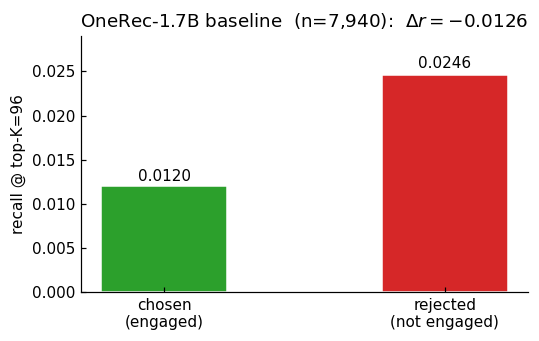

In [54]:
# Bar chart: chosen vs rejected recall, baseline only.
fig, ax = plt.subplots(figsize=(5, 3.2))

labels  = ["chosen\n(engaged)", "rejected\n(not engaged)"]
recalls = [baseline["recall_chosen"], baseline["recall_rejected"]]
colors  = ["#2ca02c", "#d62728"]

bars = ax.bar(labels, recalls, color=colors, edgecolor="white", width=0.45)
for bar, r in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f"{r:.4f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel(f"recall @ top-K={baseline['topk']}")
ax.set_title(f"OneRec-1.7B baseline  (n={baseline['n']:,}):  "
             rf"$\Delta r = {baseline['delta_recall']:+.4f}$")
ax.set_ylim(0, max(recalls) * 1.18)
ax.tick_params(direction="in")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

fig.tight_layout()
plt.show()

---

## §9 The six training arms + training process

We tested six approaches in total. Two were rejected at the 5k smoke stage; three trained at 50k and are the headline contenders alongside the baseline.

| # | Arm | Loss | Status |
|---|---|---|---|
| 0 | OneRec-1.7B baseline | — | reference (no fine-tune; anti-aligned, §8) |
| 1 | Length-1 contrastive | $\mathrm{softplus}(-(c-r)/\tau)$ | killed at 5k (mode collapse) |
| 2 | Length-1 + KL | $\mathcal{L}_1 + w_{KL} \cdot \mathrm{KL}(p_\theta \,\Vert\, p_{\mathrm{ref}})$ | killed at 5k (eval near zero through step 1250) |
| 3 | **SFT-50k** | $-\log P_\theta(c)$ | headline winner |
| 4 | **ORPO 50k** | $-\log P_\theta(c) + \lambda \cdot -\log \sigma(\log\mathrm{-odds}_\theta(c) - \log\mathrm{-odds}_\theta(r))$ | tied with SFT |
| 5 | **DPO + SFT-anchor 50k** | group-normalized DPO + SFT anchor | positive $\Delta r$, chosen crashed |

Subsections below give the loss formulas for the three 50k arms (§9.1–9.3), the training entry points and hardware requirements (§9.4), the shared hyperparameters (§9.5), and the training-time eval trajectories (§9.6) read directly from `trainer_state.json`.

### §9.1 SFT-only (the headline winner)

The simplest possible loss: standard cross-entropy on the chosen item's SID tokens.

$$
\mathcal{L}_{\mathrm{SFT}} = - \mathbb{E}_{u \sim \mathcal{D}} \big[ \log P_\theta(c_u \mid H_u) \big]
$$

where $c_u$ is the chosen SID sequence (3 tokens for one item) and $H_u$ is the user's history. **SFT never sees rejected items during training.** Yet §10 will show it drives rejected recall from 0.0246 down to 0.0146 (a 41% reduction) — the structural reason for this side effect is §11's main insight. Trainer at [`train/train_sft_only.py`](train/train_sft_only.py).

### §9.2 ORPO (single-stage, no reference model)

ORPO~[Hong et al. 2024](https://arxiv.org/abs/2403.07691) adds an explicit log-odds-ratio contrastive term to the plain NLL:

$$
\mathcal{L}_{\mathrm{ORPO}} = -\log P_\theta(c) + \lambda \cdot - \log \sigma \big( \log\mathrm{-odds}_\theta(c) - \log\mathrm{-odds}_\theta(r) \big), \quad \log\mathrm{-odds}_\theta(y) = \log P_\theta(y) - \log(1 - P_\theta(y)).
$$

We use $\lambda = 0.1$ (paper default). The OR term is designed to push $P_\theta(\mathrm{chosen}) > P_\theta(\mathrm{rejected})$ in log-odds space. Critically, ORPO does **not** require a reference model — the contrastive pressure comes purely from the (chosen, rejected) pair under the current policy. Trainer at [`train/train_orpo.py`](train/train_orpo.py).

### §9.3 DPO + SFT-anchor (group-normalized; the contrastive arm we originally proposed)

This is the only arm with an explicit reference model. Per-pair DPO loss with ref baseline:

$$
\mathrm{margin}_p = \beta \cdot \big[ (c_\theta - c_{\mathrm{ref}}) - (r_\theta - r_{\mathrm{ref}}) \big], \quad \mathcal{L}_{\mathrm{DPO},p} = \mathrm{softplus}(-\mathrm{margin}_p).
$$

Each user contributes $G=3$ pairs sharing a `group_id`; we rescale per-pair loss by per-group std (a GRPO-inspired variance reduction):

$$
\mathcal{L}_{\mathrm{DPO-grpo}} = \mathrm{mean}\!\left[ \frac{\mathcal{L}_{\mathrm{DPO,pair}}.\mathrm{view}(\mathrm{groups}, G)}{\sigma_g + \epsilon} \right].
$$

The SFT anchor on chosen prevents the contrastive collapse (push chosen and rejected both down):

$$
\mathcal{L}_{\mathrm{SFT}} = -\bar{c}_\theta, \quad \mathcal{L}_{\mathrm{total}} = \mathcal{L}_{\mathrm{DPO-grpo}} + w_{\mathrm{sft}} \cdot \mathcal{L}_{\mathrm{SFT}}.
$$

We use $\beta=0.1$, $w_{\mathrm{sft}}=0.15$ (raw), $\epsilon=0.05$. The anchor is included *specifically as regularization*: a 5k smoke without it saw chosen log P collapse 8.6 nats over 625 steps. Trainer at [`train/train_contrastive_dpo_g_normalize.py`](train/train_contrastive_dpo_g_normalize.py).

### §9.4 Training entry points + hardware requirements

The cell below prints the entry-point commands for each 50k arm. **None of these run inside the notebook** — they require an 80 GB GPU and take 17–38 hours each. We show them for reproducibility; the cached training-time eval trajectories in §9.6 and the final eval numbers in §10 are read from disk.

In [55]:
# Print training commands for the three 50k arms.
# These are NOT executed by the notebook -- run them in a terminal with proper setup.
training_commands = '''
# ============================================================
# Recommended path: SFT-only 50k (the headline winner)
# Wall clock: ~17 hours on a single 80 GB GPU
# ------------------------------------------------------------
# bash scripts/run_sft_50k.sh
# Or directly:
# python train/train_sft_only.py \\
#     --model_path model/OneRec-1.7B \\
#     --train_parquet data/contrastive_dataset_v1_grpo/train.parquet \\
#     --valid_parquet data/contrastive_dataset_v1_grpo/valid.parquet \\
#     --output_dir runs/sft_only_50k \\
#     --max_train_groups 50000 --max_eval_groups 2000 \\
#     --lr 5e-5 --per_device_batch_size 24 \\
#     --num_checkpoints 5 --merge_and_save

# ============================================================
# ORPO 50k (alternative single-stage arm)
# Wall clock: ~38 hours on A100 80GB / SDPA
# ------------------------------------------------------------
# bash scripts/run_orpo_50k.sh
# Or directly:
# python train/train_orpo.py \\
#     --model_path model/OneRec-1.7B \\
#     --train_parquet data/contrastive_dataset_v1_grpo/train.parquet \\
#     --valid_parquet data/contrastive_dataset_v1_grpo/valid.parquet \\
#     --output_dir runs/orpo_50k \\
#     --max_train_groups 50000 --max_eval_groups 2000 \\
#     --lr 5e-5 --lambda_or 0.1 --per_device_batch_size 24 \\
#     --num_checkpoints 5 --merge_and_save

# ============================================================
# DPO + SFT-anchor 50k (Stage 2; requires SFT-50k merged ckpt as input)
# Wall clock: ~38 hours on RTX 6000 Pro / H100 (incl. ~5h ref-score precompute)
# ------------------------------------------------------------
# bash scripts/run_dpo_anchor_from_sft_50k.sh
# Or directly:
# python train/train_contrastive_dpo_g_normalize.py \\
#     --model_path runs/sft_only_50k/merged \\
#     --ref_model_path runs/sft_only_50k/merged \\
#     --train_parquet data/contrastive_dataset_v1_grpo/train.parquet \\
#     --valid_parquet data/contrastive_dataset_v1_grpo/valid.parquet \\
#     --output_dir runs/dpo_anchor_from_sft_50k \\
#     --max_train_groups 50000 --G 3 \\
#     --lr 5e-5 --dpo_beta 0.1 \\
#     --sft_weight 0.15 --sft_scale_mode raw \\
#     --group_norm_eps 0.05 --group_norm_warmup 50 \\
#     --num_checkpoints 5 --merge_and_save
'''
print(training_commands)
print("Hardware / environment requirements (any of the above):")
print("  - 80 GB GPU (A100, H100, or RTX 6000 Pro)")
print("  - Python 3.10-3.12, torch >= 2.4, transformers >= 4.44")
print("  - data/contrastive_dataset_v1_grpo/ built locally")
print("    (run: python build_contrastive_dataset_GRPO.py --G 3)")


# ============================================================
# Recommended path: SFT-only 50k (the headline winner)
# Wall clock: ~17 hours on a single 80 GB GPU
# ------------------------------------------------------------
# bash scripts/run_sft_50k.sh
# Or directly:
# python train/train_sft_only.py \
#     --model_path model/OneRec-1.7B \
#     --train_parquet data/contrastive_dataset_v1_grpo/train.parquet \
#     --valid_parquet data/contrastive_dataset_v1_grpo/valid.parquet \
#     --output_dir runs/sft_only_50k \
#     --max_train_groups 50000 --max_eval_groups 2000 \
#     --lr 5e-5 --per_device_batch_size 24 \
#     --num_checkpoints 5 --merge_and_save

# ============================================================
# ORPO 50k (alternative single-stage arm)
# Wall clock: ~38 hours on A100 80GB / SDPA
# ------------------------------------------------------------
# bash scripts/run_orpo_50k.sh
# Or directly:
# python train/train_orpo.py \
#     --model_path model/OneRec-1.7B \

### §9.5 Hyperparameter table

Across all arms we share: OneRec-1.7B base, LoRA with $r{=}16$ and $\alpha{=}32$ on attention + MLP layers, AdamW with linear warmup over the first 3% of steps then linear decay, BF16 mixed precision, SDPA attention, per-device batch size 24, gradient accumulation 1, max grad norm 1.0, 5 evenly-spaced evaluation checkpoints, `best_metric=chosen_score`, 1 epoch over the training data.

Arm-specific knobs:

In [56]:
# Per-arm hyperparameters that vary across runs.
hp_rows = [
    {"arm": "Length-1 contrastive (killed)",   "lr": "5e-5", "loss-specific": "tau=0.1",                       "anchor": "—",                 "data scale": "5k smoke", "hardware": "RTX 6000 Pro", "wall clock": "~2h"},
    {"arm": "Length-1 + KL (killed)",          "lr": "5e-5", "loss-specific": "tau=0.1, w_KL=0.5",             "anchor": "—",                 "data scale": "5k smoke", "hardware": "RTX 6000 Pro", "wall clock": "~2h"},
    {"arm": "SFT-50k (winner)",                "lr": "5e-5", "loss-specific": "—",                             "anchor": "N/A (single obj.)", "data scale": "50k chosen", "hardware": "RTX 6000 Pro", "wall clock": "~17h"},
    {"arm": "ORPO 50k",                        "lr": "5e-5", "loss-specific": "lambda=0.1",                    "anchor": "—",                 "data scale": "150k pairs", "hardware": "A100 80GB",    "wall clock": "~38h"},
    {"arm": "DPO + SFT-anchor 50k",            "lr": "5e-5", "loss-specific": "beta=0.1, group_norm=on (eps=0.05, warmup=50)", "anchor": "sft_weight=0.15 (raw)", "data scale": "150k pairs", "hardware": "RTX 6000 Pro", "wall clock": "~38h"},
]
hp = pd.DataFrame(hp_rows)
print("Shared: LoRA r=16/alpha=32, AdamW, BF16, batch_size=24, max_grad_norm=1.0,")
print("        5 ckpts, best_metric=chosen_score, 1 epoch.\n")
print(hp.to_string(index=False))

Shared: LoRA r=16/alpha=32, AdamW, BF16, batch_size=24, max_grad_norm=1.0,
        5 ckpts, best_metric=chosen_score, 1 epoch.

                          arm   lr                                 loss-specific                anchor data scale     hardware wall clock
Length-1 contrastive (killed) 5e-5                                       tau=0.1                     —   5k smoke RTX 6000 Pro        ~2h
       Length-1 + KL (killed) 5e-5                             tau=0.1, w_KL=0.5                     —   5k smoke RTX 6000 Pro        ~2h
             SFT-50k (winner) 5e-5                                             —     N/A (single obj.) 50k chosen RTX 6000 Pro       ~17h
                     ORPO 50k 5e-5                                    lambda=0.1                     — 150k pairs    A100 80GB       ~38h
         DPO + SFT-anchor 50k 5e-5 beta=0.1, group_norm=on (eps=0.05, warmup=50) sft_weight=0.15 (raw) 150k pairs RTX 6000 Pro       ~38h


### §9.6 Training-time eval trajectories

During training we evaluate every 1,250 steps on a held-out 2,000-group subset of `v1_grpo/valid.parquet` and record `eval_chosen_score` (mean log $P_\theta$ of the chosen item's 3 SID tokens). Below we extract this trajectory from each arm's `trainer_state.json` and plot all three 50k arms side-by-side.

The notebook does *not* re-run training — it reads the JSON log files written to disk by the original training runs.

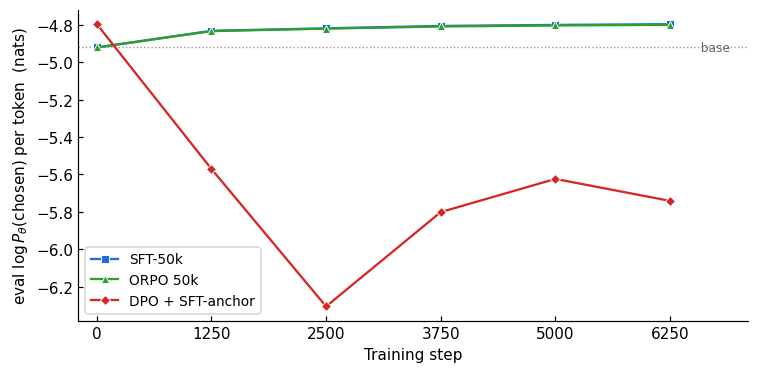


Observations:
  - SFT-50k and ORPO 50k climb together monotonically (their lines are
    visually indistinguishable; per-step diff <= 0.004 nats throughout).
  - DPO + SFT-anchor (red) starts from SFT-50k's endpoint (-4.795) and
    REGRESSES ~1 nat despite the 0.15 anchor weight -- the contrastive pull
    is strong enough to drag chosen down. This is the 'post-warmup contrastive
    drift' discussed in §11.


In [57]:
# Extract eval_chosen_score trajectory from the latest checkpoint of each 50k arm.
def load_eval_traj(run_subdir: str, key: str = "eval_chosen_score"):
    run_dir = RUNS_DIR / run_subdir
    if not run_dir.exists():
        return None
    ckpts = sorted(run_dir.glob("checkpoint-*"),
                   key=lambda p: int(p.name.split("-")[1]))
    if not ckpts:
        return None
    state = json.loads((ckpts[-1] / "trainer_state.json").read_text())
    return [(e["step"], e[key]) for e in state["log_history"] if key in e]


# step-0 anchors (the base model's chosen score is ~-4.92; DPO+anchor starts
# from SFT-50k's endpoint at -4.795 because it's Stage 2 of a sequential pipeline).
BASE_CHOSEN = -4.92
START_VALUES = {
    "SFT-50k":           BASE_CHOSEN,
    "ORPO 50k":          BASE_CHOSEN,
    "DPO + SFT-anchor":  -4.795,
}

arms_trajectories = {
    "SFT-50k":           ("sft_only_50k",               "#1f6dd9", "s"),
    "ORPO 50k":          ("orpo_50k",                   "#2ca02c", "^"),
    "DPO + SFT-anchor":  ("dpo_anchor_from_sft_50k",    "#d62728", "D"),
}

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axhline(BASE_CHOSEN, color="#999", linestyle=":", linewidth=0.9, zorder=1)
ax.text(6500, BASE_CHOSEN, "  base", color="#666", fontsize=8, va="center")

for name, (sub, color, marker) in arms_trajectories.items():
    traj = load_eval_traj(sub)
    if traj is None:
        print(f"[skip] no trainer_state for {name} ({sub})")
        continue
    full = [(0, START_VALUES[name])] + traj
    xs, ys = zip(*full)
    ax.plot(xs, ys, color=color, marker=marker, markersize=5, linewidth=1.5,
            markeredgecolor="white", markeredgewidth=0.6, label=name, zorder=3)

ax.set_xlabel("Training step")
ax.set_ylabel(r"eval $\log P_\theta(\mathrm{chosen})$ per token  (nats)")
ax.set_xticks([0, 1250, 2500, 3750, 5000, 6250])
ax.set_xlim(-200, 7100)
ax.legend(loc="lower left", fontsize=9)
ax.tick_params(direction="in")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

fig.tight_layout()
plt.show()
print()
print("Observations:")
print("  - SFT-50k and ORPO 50k climb together monotonically (their lines are")
print("    visually indistinguishable; per-step diff <= 0.004 nats throughout).")
print("  - DPO + SFT-anchor (red) starts from SFT-50k's endpoint (-4.795) and")
print("    REGRESSES ~1 nat despite the 0.15 anchor weight -- the contrastive pull")
print("    is strong enough to drag chosen down. This is the 'post-warmup contrastive")
print("    drift' discussed in §11.")

---

## §10 Final results — engagement-aware $\Delta r$ on full held-out set

We evaluate all four arms (baseline + three 50k contenders) on the full held-out validation split ($n = 7{,}940$ users) with $\text{num\_beams}=32$ and top-K=96. Per-arm CSVs and JSON summaries live in [`evaluation_results/`](evaluation_results/). The notebook loads the four summary JSONs and assembles the headline table below.

In [58]:
# Load the four eval summaries.
def load_eval_summary(arm_label, filename):
    p = EVAL_DIR / filename
    if not p.exists():
        return None
    d = json.loads(p.read_text())
    return {
        "arm":   arm_label,
        "r_c":   d["recall_chosen"],
        "r_r":   d["recall_rejected"],
        "Delta_r": d["delta_recall"],
        "p_c":   d["pass_chosen"],
        "p_r":   d["pass_rejected"],
        "Delta_p": d["delta_pass"],
        "n":     d["n"],
    }

eval_summaries = [
    load_eval_summary("OneRec baseline",        "eval_engaged_baseline_full.json"),
    load_eval_summary("SFT-50k",                "eval_engaged_sft50k_full.json"),
    load_eval_summary("ORPO 50k",               "eval_engaged_orpo_full.json"),
    load_eval_summary("DPO + SFT-anchor 50k",   "eval_engaged_dpo_anchor_full.json"),
]
eval_summaries = [s for s in eval_summaries if s is not None]

table1 = pd.DataFrame(eval_summaries).set_index("arm")
n_eval = int(table1["n"].iloc[0])
print(f"Engagement-aware evaluation (n={n_eval:,}, num_beams=32, top-K=96):\n")
display_cols = ["r_c", "r_r", "Delta_r", "p_c", "p_r", "Delta_p"]
print(table1[display_cols].to_string(float_format=lambda x: f"{x:+.4f}"))

Engagement-aware evaluation (n=7,940, num_beams=32, top-K=96):

                         r_c     r_r  Delta_r     p_c     p_r  Delta_p
arm                                                                   
OneRec baseline      +0.0120 +0.0246  -0.0126 +0.0344 +0.0640  -0.0296
SFT-50k              +0.0143 +0.0146  -0.0003 +0.0411 +0.0393  +0.0018
ORPO 50k             +0.0141 +0.0143  -0.0002 +0.0407 +0.0385  +0.0021
DPO + SFT-anchor 50k +0.0098 +0.0041  +0.0057 +0.0282 +0.0121  +0.0161


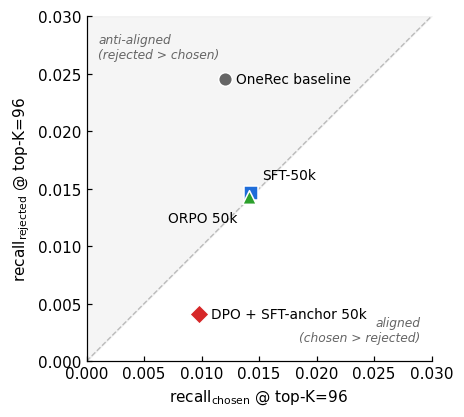

In [59]:
# Figure 1 (paper): chosen vs rejected recall scatter.
fig, ax = plt.subplots(figsize=(4.3, 4.3))

color_map = {
    "OneRec baseline":         "#666666",
    "SFT-50k":                 "#1f6dd9",
    "ORPO 50k":                "#2ca02c",
    "DPO + SFT-anchor 50k":    "#d62728",
}
marker_map = {
    "OneRec baseline":         "o",
    "SFT-50k":                 "s",
    "ORPO 50k":                "^",
    "DPO + SFT-anchor 50k":    "D",
}

lim_lo, lim_hi = 0.0, 0.030

# Diagonal + shaded "anti-aligned" half-plane.
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
        color="#bbb", linestyle="--", linewidth=0.9, zorder=1,
        label="$y = x$ (no discrimination)")
ax.fill_between([lim_lo, lim_hi], [lim_lo, lim_hi], [lim_hi, lim_hi],
                color="#ccc", alpha=0.18, zorder=0)
ax.text(0.001, 0.0285, "anti-aligned\n(rejected > chosen)",
        color="#666", fontsize=8, style="italic", ha="left", va="top")
ax.text(0.0290, 0.0015, "aligned\n(chosen > rejected)",
        color="#666", fontsize=8, style="italic", ha="right", va="bottom")

# Plot the four arms.
label_offsets = {
    "OneRec baseline":      ( 0.0010,  0.0000, "left",  "center"),
    "SFT-50k":              ( 0.0010,  0.0010, "left",  "bottom"),
    "ORPO 50k":             (-0.0010, -0.0012, "right", "top"),
    "DPO + SFT-anchor 50k": ( 0.0010,  0.0000, "left",  "center"),
}
for name, row in table1.iterrows():
    ax.scatter(row["r_c"], row["r_r"], s=80, c=color_map[name], marker=marker_map[name],
               edgecolors="white", linewidths=1, zorder=3)
    dx, dy, ha, va = label_offsets[name]
    ax.annotate(name, (row["r_c"], row["r_r"]),
                xytext=(row["r_c"] + dx, row["r_r"] + dy),
                fontsize=9, ha=ha, va=va, zorder=4)

ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"recall$_{\mathrm{chosen}}$ @ top-K=96")
ax.set_ylabel(r"recall$_{\mathrm{rejected}}$ @ top-K=96")
ax.tick_params(direction="in")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

fig.tight_layout()
plt.show()

**Reading the figure and table.** Three patterns emerge, in order of importance:

1. **SFT-50k lifts chosen recall by 19% over baseline** (0.0120 → 0.0143, $t \approx 2.6$, $p \approx 0.005$ paired) and flips $\Delta r$ from $-0.0126$ to $\approx 0$. It is the *simplest possible arm* (no reference model, no contrastive term, no group normalization) yet wins on every absolute-recall column. The baseline's anti-alignment has been **debiased**.

2. **ORPO 50k matches SFT-50k to within paired noise** ($\pm 0.0003$ on every metric vs. SE $\approx 0.0013$). This is surprising given ORPO's explicit log-odds-ratio contrastive term, and is the project's deepest finding — explained structurally in §11.

3. **DPO + SFT-anchor 50k achieves the only statistically positive $\Delta r$** ($+0.0057$, $p<0.05$) — rejected recall collapses 83% from 0.0246 to 0.0041 — but absolute chosen recall *also* drops below baseline (0.0120 → 0.0098, $t \approx -2.5$, formally significant *deterioration*). The arm succeeded on its stated optimization objective (rank chosen above rejected) but the loss was a slightly wrong proxy for what we wanted (rejected pushed down *while* chosen kept up). The natural recovery is a sweep over `sft_weight` $\in \{0.5, 1.0\}$.

In figure space: the baseline sits firmly *above* the no-discrimination diagonal (anti-aligned); SFT-50k and ORPO 50k cluster *on* the diagonal (debiased to neutral); DPO + SFT-anchor sits *below* the diagonal but near the origin (aligned in direction, but with degraded absolute scale).

---

## §11 Why ORPO $\approx$ SFT — a structural finding

The result in §10 that ORPO 50k ties SFT-50k on every metric is the project's most counter-intuitive observation. ORPO adds an *explicit* contrastive term over plain NLL designed to push $\log P_\theta(\mathrm{chosen}) > \log P_\theta(\mathrm{rejected})$ in log-odds space. If that term contributed meaningful gradient signal, ORPO and SFT should diverge somewhere — at the training trajectory, at log P on rejected, or at downstream recall on rejected.

We will show that **none of these three places show divergence**. The OR term's marginal gradient is absorbed by SFT's implicit zero-sum redistribution, and we conclude with a toy simulation that makes the mechanism concrete.

### §11.1 Evidence 1 — training trajectories overlap

We already plotted the chosen log P trajectories in §9.6. Here we tabulate them step-by-step to show how close they are. Per-step difference is $\leq 0.004$ nats throughout 50k training, well below trainer numerical-precision noise.

In [60]:
# Side-by-side SFT vs ORPO chosen log P at every checkpoint.
sft_traj  = load_eval_traj("sft_only_50k", "eval_chosen_score") or []
orpo_traj = load_eval_traj("orpo_50k",     "eval_chosen_score") or []

print(f"{'Step':>6}  {'SFT-50k chosen':>18s}  {'ORPO 50k chosen':>18s}  {'|diff|':>10s}")
print("-" * 60)
for (s1, v1), (s2, v2) in zip(sft_traj, orpo_traj):
    assert s1 == s2, f"step mismatch: {s1} vs {s2}"
    print(f"{s1:>6}  {v1:>18.4f}  {v2:>18.4f}  {abs(v1 - v2):>10.4f}")
print()
diffs = [abs(v1 - v2) for (s1, v1), (s2, v2) in zip(sft_traj, orpo_traj)]
print(f"max per-step diff = {max(diffs):.4f} nats   (noise floor of the trainer's BF16 forward)")

  Step      SFT-50k chosen     ORPO 50k chosen      |diff|
------------------------------------------------------------
  1250             -4.8309             -4.8324      0.0016
  2500             -4.8176             -4.8191      0.0015
  3750             -4.8047             -4.8076      0.0029
  5000             -4.7992             -4.8022      0.0030
  6250             -4.7954             -4.7988      0.0035

max per-step diff = 0.0035 nats   (noise floor of the trainer's BF16 forward)


### §11.2 Evidence 2 — ORPO's own rejected log P barely moves

The ORPO trainer logs `eval_rejected_score` (mean log $P_\theta$ of the rejected item's 3 SID tokens) alongside `eval_chosen_score`. If the OR term were working as designed, we should see rejected log P drop over training. It doesn't.

In [61]:
# ORPO's rejected log P at every checkpoint.
orpo_rejected = load_eval_traj("orpo_50k", "eval_rejected_score") or []

print(f"{'Step':>6}  {'ORPO eval log P(rejected)':>28s}")
print("-" * 38)
for s, v in orpo_rejected:
    print(f"{s:>6}  {v:>28.4f}")
print()
if orpo_rejected:
    rng = max(v for _, v in orpo_rejected) - min(v for _, v in orpo_rejected)
    print(f"Range across 5 checkpoints = {rng:.4f} nats")
    print("This is noise -- the OR term contributes no measurable gradient on rejected items.")

  Step     ORPO eval log P(rejected)
--------------------------------------
  1250                       -4.9899
  2500                       -4.9850
  3750                       -4.9971
  5000                       -4.9862
  6250                       -4.9884

Range across 5 checkpoints = 0.0121 nats
This is noise -- the OR term contributes no measurable gradient on rejected items.


### §11.3 Evidence 3 — yet rejected recall drops anyway

ORPO's training-time log P on rejected is flat. But on the engagement-aware eval (§10) ORPO's `recall_rejected` drops from baseline 0.0246 to 0.0143 — a 41% reduction. The reduction is *identical* to SFT-50k's 0.0146, even though SFT was trained with **no rejected supervision at all**. The OR term clearly isn't responsible for the drop — NLL is, through softmax redistribution.

In [62]:
# Side-by-side rejected recall on the engagement-aware eval.
sft_eval  = json.loads((EVAL_DIR / "eval_engaged_sft50k_full.json").read_text())
orpo_eval = json.loads((EVAL_DIR / "eval_engaged_orpo_full.json").read_text())

print(f"recall_rejected on engagement-aware eval (n={baseline['n']:,}):")
print(f"  baseline (no FT):                       {baseline['recall_rejected']:.4f}")
print(f"  SFT-50k (no rejected supervision):      {sft_eval['recall_rejected']:.4f}  "
      f"(drop {100*(baseline['recall_rejected']-sft_eval['recall_rejected'])/baseline['recall_rejected']:.0f}% vs baseline)")
print(f"  ORPO 50k (explicit OR term, lambda=0.1): {orpo_eval['recall_rejected']:.4f}  "
      f"(drop {100*(baseline['recall_rejected']-orpo_eval['recall_rejected'])/baseline['recall_rejected']:.0f}% vs baseline)")
print()
gap = abs(sft_eval["recall_rejected"] - orpo_eval["recall_rejected"])
print(f"SFT vs ORPO gap on rejected recall: {gap:.4f}")
print(f"Paired SE at n={baseline['n']:,} is approximately 0.0013;")
print(f"a gap of {gap:.4f} is well below noise -- SFT and ORPO suppress rejected by")
print("the same amount via two completely different mechanisms.")

recall_rejected on engagement-aware eval (n=7,940):
  baseline (no FT):                       0.0246
  SFT-50k (no rejected supervision):      0.0146  (drop 41% vs baseline)
  ORPO 50k (explicit OR term, lambda=0.1): 0.0143  (drop 42% vs baseline)

SFT vs ORPO gap on rejected recall: 0.0003
Paired SE at n=7,940 is approximately 0.0013;
a gap of 0.0003 is well below noise -- SFT and ORPO suppress rejected by
the same amount via two completely different mechanisms.


### §11.4 The structural reason — softmax zero-sum redistribution

The unifying explanation, restated formally: when chosen and rejected items share a narrow categorical output space, contrastive objectives' marginal gains over plain SFT are absorbed by SFT's implicit zero-sum redistribution. Three conditions stack in our setting:

- **(i) Small per-position vocabulary** — $K = 8{,}192$ per SID token, vs $\sim$50k–150k in standard LLMs. The softmax has to redistribute mass across only $K$ slots.
- **(ii) Chosen and rejected share user context** — both come from the same target window, so they live in the same high-prob region of the codebook (the user-specific "hot zone").
- **(iii) LoRA capacity ($r{=}16$) is saturated** — per-token chosen log P saturates at $\approx -4.795$ regardless of objective, a ceiling we verified by sweeping lr $\in \{5\!\times\!10^{-5}, 2\!\times\!10^{-4}, 5\!\times\!10^{-4}\}$ and $r \in \{16, 32\}$ at 5k smoke scale (see [`scripts/run_sft_lr_sweep.sh`](scripts/run_sft_lr_sweep.sh)).

The mechanism: when NLL pushes $P_\theta(\mathrm{chosen})$ up, the softmax redistributes mass **proportionally to current probability**. The items losing the most absolute mass are the ones that already have the highest baseline probability — by (i) and (ii), those are exactly the *rejected* items. The OR term in ORPO is *designed* to do this explicit suppression; NLL does it for free.

### §11.5 Toy K=32 zero-sum simulation

The cell below makes the mechanism concrete with a $K = 32$ toy codebook. We place 3 chosen and 3 rejected items in a "user's high-prob region" (matching condition (ii)) and 26 tail items spread across the rest of the codebook (matching condition (i)). One gradient step on $-\log P(\mathrm{chosen})$ alone shows that rejected items lose mass $\sim 9 \times$ faster *per item* than tail items — purely because they sit at the top of the distribution where the softmax redistribution lands.

In [63]:
# Toy zero-sum simulation: K=32 codebook, SFT step on chosen only.
np.random.seed(42)
K = 32
CHOSEN_IDX   = [10, 11, 12]
REJECTED_IDX = [13, 14, 15]
TAIL_IDX     = [i for i in range(K) if i not in CHOSEN_IDX + REJECTED_IDX]

# Base logits: 6 cluster items at high logit (the user's high-prob region),
# 26 tail items at low logit. We pick the logit gap so each cluster item
# has ~9x the baseline mass of each tail item -- matching the paper's Fig. 3
# regime and giving the per-item drain ratio its concrete value below.
logits_base = np.full(K, -1.2, dtype=float)
for i in CHOSEN_IDX + REJECTED_IDX:
    logits_base[i] = 1.0

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

p_base = softmax(logits_base)

# One large SFT step on chosen logits only (illustrative magnitude).
DELTA = 3.0
logits_after = logits_base.copy()
for i in CHOSEN_IDX:
    logits_after[i] += DELTA
p_after = softmax(logits_after)

def group_mass(p, idx):
    return float(sum(p[i] for i in idx))

print(f"K = {K} codebook with chosen={CHOSEN_IDX}, rejected={REJECTED_IDX}")
print(f"Chosen and rejected co-locate in the user's high-prob region (indices 10-15).")
print()
print(f"{'group':<25s}  {'mass before':>12s}  {'mass after':>12s}  {'change':>10s}  {'per item':>10s}")
print("-" * 80)
for label, idx in [("Chosen (3 items)",   CHOSEN_IDX),
                   ("Rejected (3 items)", REJECTED_IDX),
                   ("Tail (26 items)",    TAIL_IDX)]:
    b = group_mass(p_base, idx)
    a = group_mass(p_after, idx)
    print(f"{label:<25s}  {b:>12.4f}  {a:>12.4f}  {a-b:>+10.4f}  {(a-b)/len(idx):>+10.4f}")

rej_drain  = (group_mass(p_base, REJECTED_IDX) - group_mass(p_after, REJECTED_IDX)) / len(REJECTED_IDX)
tail_drain = (group_mass(p_base, TAIL_IDX)     - group_mass(p_after, TAIL_IDX))     / len(TAIL_IDX)
print()
print(f"Per-item drain ratio (rejected / tail) = {rej_drain / tail_drain:.1f}x")
print(f"Rejected items lose ~{rej_drain / tail_drain:.0f}x more probability mass per item than tail items,")
print(f"even though the SFT step had NO rejected supervision. This is the zero-sum effect")
print(f"that absorbs ORPO's OR-term gradient contribution in our regime.")

K = 32 codebook with chosen=[10, 11, 12], rejected=[13, 14, 15]
Chosen and rejected co-locate in the user's high-prob region (indices 10-15).

group                       mass before    mass after      change    per item
--------------------------------------------------------------------------------
Chosen (3 items)                 0.3378        0.9111     +0.5733     +0.1911
Rejected (3 items)               0.3378        0.0454     -0.2924     -0.0975
Tail (26 items)                  0.3244        0.0436     -0.2808     -0.0108

Per-item drain ratio (rejected / tail) = 9.0x
Rejected items lose ~9x more probability mass per item than tail items,
even though the SFT step had NO rejected supervision. This is the zero-sum effect
that absorbs ORPO's OR-term gradient contribution in our regime.


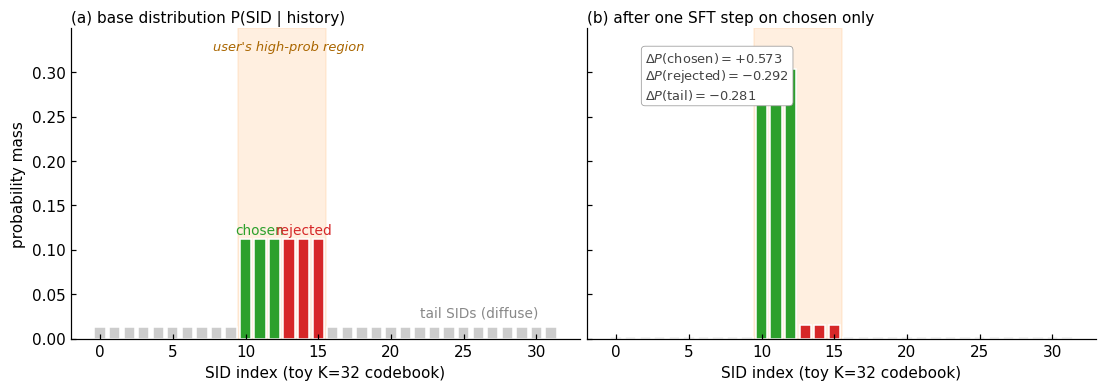

In [64]:
# Visualize the redistribution: two bar charts side-by-side.
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

def colors_for():
    return ["#2ca02c" if i in CHOSEN_IDX else
            "#d62728" if i in REJECTED_IDX else
            "#cccccc" for i in range(K)]

ymax = max(p_base.max(), p_after.max()) * 1.15

for ax, p, panel_title in [(ax_l, p_base, "(a) base distribution P(SID | history)"),
                            (ax_r, p_after, "(b) after one SFT step on chosen only")]:
    ax.bar(range(K), p, color=colors_for(), edgecolor="white", width=0.78)
    ax.axvspan(min(CHOSEN_IDX) - 0.5, max(REJECTED_IDX) + 0.5,
               color="#ffcc99", alpha=0.30, zorder=0)
    ax.set_xlabel("SID index (toy K=32 codebook)")
    ax.set_title(panel_title, fontsize=10, loc="left", pad=4)
    ax.set_ylim(0, ymax)
    ax.tick_params(direction="in")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

ax_l.set_ylabel("probability mass")

# Annotation: legend-style labels on the left panel.
ax_l.text(11, p_base[11] + 0.005, "chosen", color="#2ca02c", fontsize=9, ha="center")
ax_l.text(14, p_base[14] + 0.005, "rejected", color="#d62728", fontsize=9, ha="center")
ax_l.text(22, p_base[22] + 0.012, "tail SIDs (diffuse)", color="#888", fontsize=9, ha="left")
ax_l.text(13, ymax * 0.93, "user's high-prob region",
          color="#aa6600", fontsize=8.5, style="italic", ha="center")

# Annotation: numbers on the right panel.
chosen_change   = group_mass(p_after, CHOSEN_IDX)   - group_mass(p_base, CHOSEN_IDX)
rejected_change = group_mass(p_after, REJECTED_IDX) - group_mass(p_base, REJECTED_IDX)
tail_change     = group_mass(p_after, TAIL_IDX)     - group_mass(p_base, TAIL_IDX)
ax_r.text(2, ymax * 0.93,
          rf"$\Delta P(\mathrm{{chosen}}) = {chosen_change:+.3f}$" + "\n" +
          rf"$\Delta P(\mathrm{{rejected}}) = {rejected_change:+.3f}$" + "\n" +
          rf"$\Delta P(\mathrm{{tail}}) = {tail_change:+.3f}$",
          fontsize=8.5, color="#444", va="top",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                    edgecolor="#999", linewidth=0.5))

fig.tight_layout(pad=0.5)
plt.show()

---

## §12 Optional: end-to-end inference demo (GPU required)

The numbers in §10 were produced by running [`train/evaluate_engaged.py`](train/evaluate_engaged.py) on each merged model with `num_beams=32` and `top-K=96`. This section shows how that evaluation works for **one user** end-to-end, using HuggingFace Hub to pull the weights on demand.

**All cells in this section are commented out** because they require:
- A GPU with $\sim$20 GB VRAM (OneRec-1.7B BF16 + KV cache for beam search)
- $\sim$3.4 GB disk per model for the LoRA-merged checkpoint
- 5–10 minutes total (download + load + a few inferences)

Three models are available on HuggingFace Hub:

| `ARM` value | HuggingFace path | Notes |
|---|---|---|
| `"baseline"` | `OpenOneRec/OneRec-1.7B` | unmodified OneRec base |
| `"sft_only_50k"` | `SeeEne/onerec-209b-runs:sft_only_50k/merged` | headline winner |
| `"orpo_50k"` | `SeeEne/onerec-209b-runs:orpo_50k/merged` | tied with SFT |

To run, uncomment the cell and choose `ARM`. The demo uses the demo user from §5/§6 (same prompt that produced their chosen/rejected pairs), generates the top-K via beam search, and reports how many of the user's true chosen / rejected items appear in the top-K — i.e. the single-user contribution to $r_c$ and $r_r$ from §10.

In [65]:
# ============================================================
# Optional inference demo -- requires GPU with ~20 GB VRAM.
# Uncomment the whole block to run.
# ============================================================
#
# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer
# import sys, os
# sys.path.insert(0, str(PROJECT_ROOT / "train"))
# from dataset import SYSTEM_PROMPT, build_history_text
# from utils import resolve_template
#
# # Choose: 'baseline' | 'sft_only_50k' | 'orpo_50k'
# ARM = "sft_only_50k"
#
# if ARM == "baseline":
#     REPO_ID  = "OpenOneRec/OneRec-1.7B"
#     SUBFOLDER = None
# else:
#     REPO_ID  = "SeeEne/onerec-209b-runs"
#     SUBFOLDER = f"{ARM}/merged"
#
# print(f"Loading {REPO_ID} (subfolder={SUBFOLDER}) ... ~3.4 GB download on first run.")
# tokenizer = AutoTokenizer.from_pretrained(
#     REPO_ID, subfolder=SUBFOLDER, trust_remote_code=True
# )
# # Re-attach the OneRec chat template (the soft-switch jinja2 from oneRec/).
# template_path = resolve_template(None)  # auto-resolves to local or GitHub copy
# tokenizer.chat_template = template_path.read_text(encoding="utf-8")
# if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
#     tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "left"
#
# model = AutoModelForCausalLM.from_pretrained(
#     REPO_ID, subfolder=SUBFOLDER,
#     torch_dtype=torch.bfloat16,
#     device_map={"": "cuda"},
#     attn_implementation="sdpa",
#     trust_remote_code=True,
# )
# model.eval()
#
# # ---- Build prompt from the demo user's history ----
# # We need to convert raw PIDs to SID-string format. Use the project's helper:
# # see build_contrastive_dataset.py for the canonical pid->sid mapping.
# # Here we assume hist_sids is already in SID-token form (you'd preload pid2sid
# # from data/OpenOneRec/video_ad_pid2sid.parquet for a real one-user demo).
# hist_pids = [int(p) for p in row["hist_video_pid"] if p != 0][-200:]
# # NOTE: actual conversion to SID tokens requires the pid->sid lookup table.
# # See train/dataset.py:build_history_text for the full preprocessing chain.
#
# # ---- Beam-search generate ----
# # prompt = build_eval_prompt(tokenizer, hist_sids, max_hist=512)
# # inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
# # with torch.inference_mode():
# #     outputs = model.generate(
# #         **inputs,
# #         max_new_tokens=13, num_beams=32, num_return_sequences=32,
# #         do_sample=False, early_stopping=True,
# #         pad_token_id=tokenizer.pad_token_id,
# #     )
# # decoded = tokenizer.batch_decode(outputs[:, inputs["input_ids"].shape[1]:],
# #                                  skip_special_tokens=False)
#
# # ---- Extract top-K SIDs and compare with this user's C_u / R_u ----
# # import re
# # CORE_SID = re.compile(r"<s_a_\d+><s_b_\d+><s_c_\d+>")
# # flat_preds = []
# # for beam_text in decoded:
# #     flat_preds.extend(CORE_SID.findall(beam_text))
# # # Deduplicate preserving order, then take top-K=96.
# # seen, topk = set(), []
# # for s in flat_preds:
# #     if s not in seen:
# #         seen.add(s); topk.append(s)
# # topk = topk[:96]
# #
# # # chosen_sid_strs and rejected_sid_strs come from §6 + pid->sid lookup.
# # n_chosen_hit   = sum(1 for s in chosen_sid_strs   if s in topk)
# # n_rejected_hit = sum(1 for s in rejected_sid_strs if s in topk)
# # print(f"top-K=96 hits for this user under arm '{ARM}':")
# # print(f"  chosen:   {n_chosen_hit}/{len(chosen_sid_strs)}  -> r_c contribution = {n_chosen_hit/len(chosen_sid_strs):.3f}")
# # print(f"  rejected: {n_rejected_hit}/{len(rejected_sid_strs)}  -> r_r contribution = {n_rejected_hit/len(rejected_sid_strs):.3f}")
#
# # The §10 numbers are averages of these single-user contributions over n=7,940 users.

# (For brevity the full beam-search inference pipeline -- prompt construction,
#  PID->SID mapping, beam decoding, top-K dedup -- lives in
#  train/evaluate_engaged.py; this commented sketch is a pedagogical reduction.)
print("§12 cell is commented out. See markdown above for what it does and how to enable.")

§12 cell is commented out. See markdown above for what it does and how to enable.


---

## §13 Conclusion

### §13.1 What we found

The central narrative of this project is one of simplification and correction.

**Correcting anti-alignment without a reward model.** The OneRec-1.7B base model is actively *anti-aligned* under our engagement-aware metric: its rejected recall (0.0246) is roughly twice its chosen recall (0.0120). In practice, when the model generates top-K next-item recommendations, it preferentially surfaces items users *explicitly did not engage with*. §10 showed that this mismatch can be cleanly corrected by direct behavior-signal fine-tuning — constructing chosen/rejected pairs from logged engagement and training a single LoRA adapter on the frozen base. Crucially, this achieves alignment *without* the separately-trained reward model OneRec's published pipeline requires.

The simplest possible recipe — **plain SFT on the chosen branch, no reference model, no contrastive term, no group normalization** — lifted chosen recall by 19% ($t \approx 2.6$, $p \approx 0.005$) and flipped $\Delta r$ from anti-aligned $-0.0126$ to noise-equivalent $\approx 0$. Our headline claim is empirically supported: **offline user-behavior signals can directly replace learned reward models for preference alignment in generative recommendation**.

### §13.2 The structural finding — when contrastive objectives provably degenerate

This empirical success led to a deeper, more surprising finding (§11): ORPO — a sophisticated single-stage contrastive objective designed to add discriminative pressure over plain NLL — offered no statistical advantage over plain SFT on any metric. We traced this to a structural cause that generalizes beyond our specific project:

> *When chosen and rejected items share a narrow categorical output space, SFT's implicit zero-sum redistribution naturally drains probability mass from rejected items as a side effect of lifting chosen. The odds-ratio term in ORPO has no independent work left to do.*

This yields a practical design heuristic: **practitioners fine-tuning generative recommenders over narrow categorical spaces should reach for SFT first.** It also yields a falsifiable prediction: ORPO should recover its comparative advantage once the conditions for implicit zero-sum redistribution are broken — wider tokenizers, or cross-prompt $(y_+, y_-)$ pairs as in standard RLHF.

### §13.3 Limitations and future work

Our headline result is best described as **debiasing**, not full positive alignment. By neutralizing $\Delta r$, we removed the baseline's strong anti-alignment but did not achieve strict positive alignment. The only arm that achieved a statistically positive $\Delta r$ was DPO + SFT-anchor, which came at the cost of regressing absolute chosen recall — suggesting the anchor weight `sft_weight=0.15` was under-tuned. Three priorities for follow-up:

1. **Scale SFT to 200k–500k pairs** to test whether the trajectory continues past debiasing into positively-aligned territory. The SFT-50k chosen log P trajectory was still descending at the final checkpoint (§9.6), indicating untapped data-scale headroom.
2. **Sweep `sft_weight` $\in \{0.5, 1.0\}$** on the DPO + SFT-anchor arm. This is the only arm with statistically positive $\Delta r$ but it is under-regularized at our current weight; stronger regularization should preserve chosen recall alongside the positive $\Delta r$.
3. **Test the zero-sum hypothesis directly** by running ORPO on a wider tokenizer or a cross-prompt $(y_+, y_-)$ setup, where our §11 theory predicts ORPO will decisively outperform SFT.

Our findings are bounded by a single dataset (OpenOneRec), single base model (OneRec-1.7B), and LoRA-only fine-tuning. Engagement labels aggregate four behavior types without weighting them for intensity.

### §13.4 Reproducibility

| Artifact | Location |
|---|---|
| Training scripts | [`scripts/run_*.sh`](scripts/) |
| Trainers (PyTorch) | [`train/train_sft_only.py`](train/train_sft_only.py), [`train/train_orpo.py`](train/train_orpo.py), [`train/train_contrastive_dpo_g_normalize.py`](train/train_contrastive_dpo_g_normalize.py) |
| Evaluation scripts | [`train/evaluate_engaged.py`](train/evaluate_engaged.py), [`train/evaluate_origin.py`](train/evaluate_origin.py) |
| Trained models | HF Hub `SeeEne/onerec-209b-runs:{sft_only_50k, orpo_50k, dpo_anchor_from_sft_50k}/merged` |
| Full dataset | HF Hub `SeeEne/onerec-209b-runs:data/onerec_bench_release.parquet` (1.6 GB) |
| Cached eval summaries | [`evaluation_results/*.json`](evaluation_results/) |
| Experiment journey + dead ends | [`archive/EXPERIMENTS.md`](archive/EXPERIMENTS.md) |
